# Business Analytics — Assignment 2: Predictive Analytics & Managerial AI Adoption
## ABC Ltd: Loan Default Risk Advisor

**Business problem.** ABC Ltd is a retail lender. About **3 in 10 loans end in default**. Every default means lost principal, collection costs and time. Credit officers want to know, **before sanctioning a loan: how likely is this applicant to default, why, and what terms would make the loan safer?**

**Decision it supports.** Approve on standard terms, approve with conditions (guarantor, collateral, shorter tenure, smaller amount), or refer to the credit committee.

| Model | Type | Target | Managerial question |
|---|---|---|---|
| Model 1 | **Linear regression** | Loan `amount` | What loan size do similar borrowers typically take? Is this request unusually large? |
| Model 2 | **Logistic regression** | `default` (Yes/No) | What is the probability this applicant defaults, and which factors drive it? |

**Data.** Statlog German Credit data (1,000 past loans, 20 applicant and loan attributes), from the UCI Machine Learning Repository, also on Kaggle. The lender is referred to as **ABC Ltd**. Category labels were rewritten in plain English, and amounts are treated as generic currency units.

**Workflow.** Colab (build and test the models) → GitHub (store code and data) → Streamlit Community Cloud (deploy the tool) → survey of credit managers (qualitative study).

## 1. Setup and data loading

In [1]:
import warnings, json, os
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
raw = pd.read_csv(DATA_URL)
print(raw.shape)
raw.head()

(1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


## 2. Data cleaning and plain-English labels

In [3]:
RELABEL = {
    "status": {"no checking account": "No current account", "... < 100 DM": "Low / overdrawn balance",
               "0 <= ... < 200 DM": "Moderate balance",
               "... >= 200 DM / salary for at least 1 year": "High balance / salary account"},
    "credit_history": {"existing credits paid back duly till now": "Current loans paid on time",
                       "critical account/other credits existing": "Has loans at other lenders",
                       "delay in paying off in the past": "Delays in the past",
                       "all credits at this bank paid back duly": "All loans with us repaid",
                       "no credits taken/all credits paid back duly": "No loans / all repaid"},
    "savings": {"... < 100 DM": "Very low (< 100)", "unknown/no savings account": "None / unknown",
                "100 <= ... < 500 DM": "Low (100–500)", "500 <= ... < 1000 DM": "Medium (500–1,000)",
                "... >= 1000 DM": "High (1,000+)"},
    "employment_duration": {"unemployed": "Unemployed", "... < 1 year": "Less than 1 year",
                            "1 <= ... < 4 years": "1–4 years", "4 <= ... < 7 years": "4–7 years",
                            "... >= 7 years": "7+ years"},
    "other_debtors": {"none": "None", "guarantor": "Guarantor", "co-applicant": "Co-applicant"},
    "property": {"real estate": "Real estate",
                 "building society savings agreement/life insurance": "Savings plan / life insurance",
                 "car or other": "Vehicle or other", "unknown/no property": "No property"},
    "other_installment_plans": {"none": "None", "bank": "With another bank", "stores": "With stores"},
    "housing": {"own": "Own", "rent": "Rent", "for free": "Lives free (family)"},
    "job": {"unemployed/unskilled - non-resident": "Unemployed / unskilled (non-resident)",
            "unskilled - resident": "Unskilled", "skilled employee/official": "Skilled employee",
            "management/self-employed/highly qualified employee/officer": "Manager / self-employed / professional"},
    "purpose": {"car (new)": "New vehicle", "car (used)": "Used vehicle", "furniture/equipment": "Furniture / equipment",
                "radio/television": "Electronics", "domestic appliances": "Home appliances", "repairs": "Repairs",
                "education": "Education", "retraining": "Skill training", "business": "Business", "others": "Other"},
    "telephone": {"no": "No", "yes": "Yes"},
}
df = raw.copy()
for col, m in RELABEL.items():
    df[col] = df[col].replace(m)
df["default"] = 1 - df["credit_risk"]          # original: 1 = good, 0 = bad  ->  default: 1 = defaulted

print("Missing values:", df.isna().sum().sum(), "| Duplicates:", df.duplicated().sum())
print(f"Default rate: {df.default.mean():.0%}  ({df.default.sum()} of {len(df)} loans)")
df.describe().T.round(1)

Missing values: 0 | Duplicates: 0
Default rate: 30%  (300 of 1000 loans)


,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.9,12.1,4.0,12.0,18.0,24.0,72.0
amount,1000.0,3271.3,2822.7,250.0,1365.5,2319.5,3972.2,18424.0
installment_rate,1000.0,3.0,1.1,1.0,2.0,3.0,4.0,4.0
present_residence,1000.0,2.8,1.1,1.0,2.0,3.0,4.0,4.0
age,1000.0,35.5,11.4,19.0,27.0,33.0,42.0,75.0
number_credits,1000.0,1.4,0.6,1.0,1.0,1.0,2.0,4.0
people_liable,1000.0,1.2,0.4,1.0,1.0,1.0,1.0,2.0
credit_risk,1000.0,0.7,0.5,0.0,0.0,1.0,1.0,1.0
default,1000.0,0.3,0.5,0.0,0.0,0.0,1.0,1.0


The data is complete, with no missing values and no duplicates. **30% of loans defaulted**, so the classes are imbalanced. We therefore judge the logistic model on recall (the share of defaulters caught) and AUC, not on accuracy alone.

**Fairness choice.** `personal_status_sex` (sex and marital status) and `foreign_worker` are **excluded** from both models. A lending tool should not score people differently on these grounds.

## 3. Exploratory data analysis

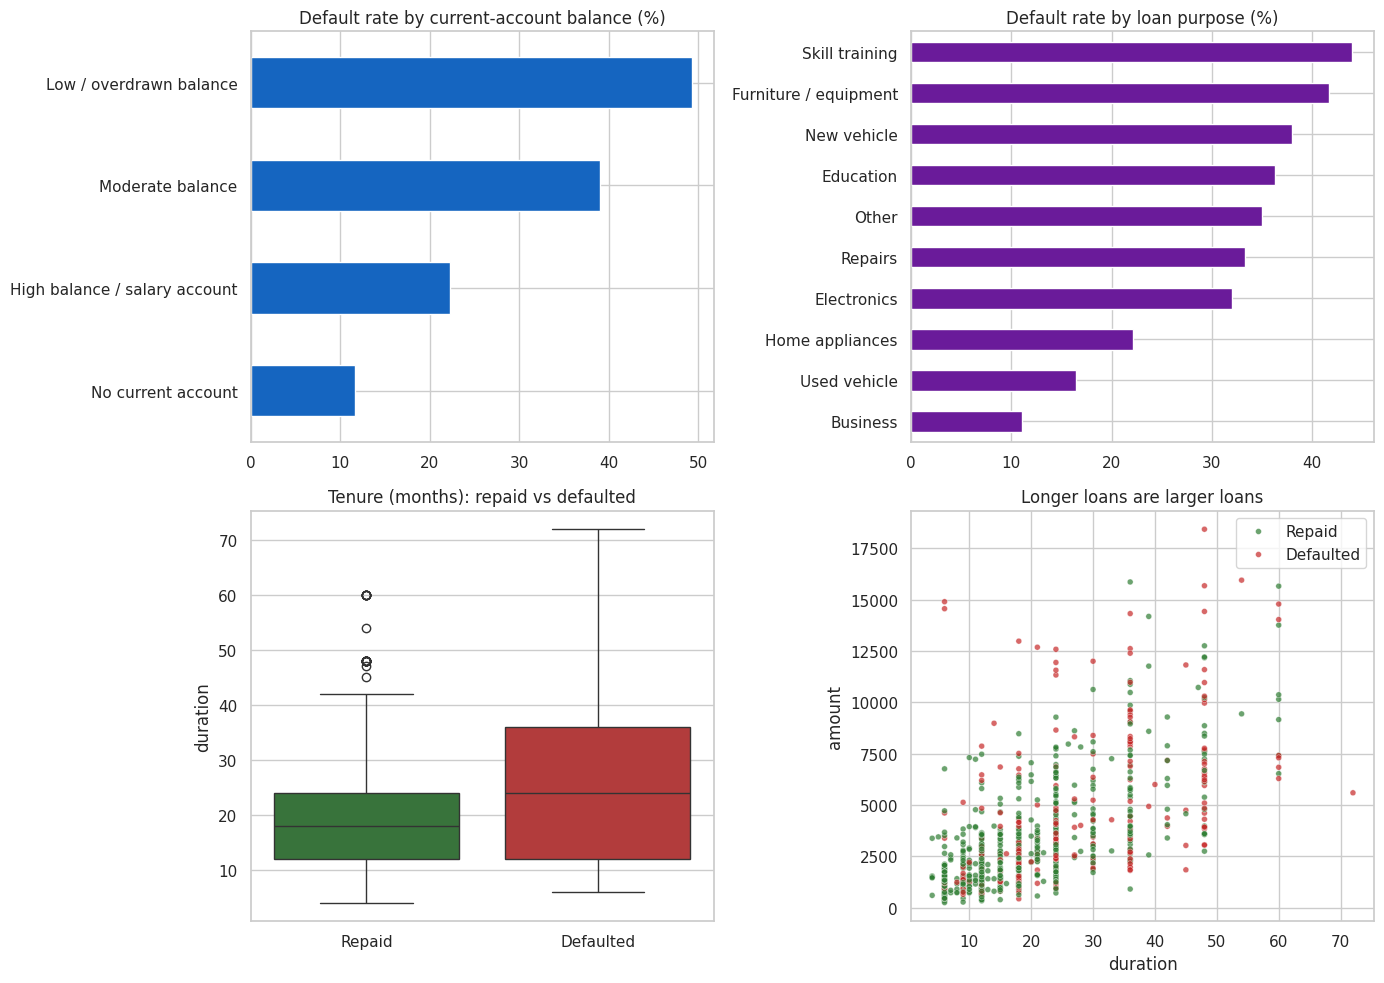

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
order = ["No current account", "High balance / salary account", "Moderate balance", "Low / overdrawn balance"]
(df.groupby("status").default.mean().reindex(order) * 100).plot.barh(ax=ax[0, 0], color="#1565c0")
ax[0, 0].set_title("Default rate by current-account balance (%)"); ax[0, 0].set_ylabel("")

(df.groupby("purpose").default.mean().sort_values() * 100).plot.barh(ax=ax[0, 1], color="#6a1b9a")
ax[0, 1].set_title("Default rate by loan purpose (%)"); ax[0, 1].set_ylabel("")

sns.boxplot(data=df, x="default", y="duration", ax=ax[1, 0], palette=["#2e7d32", "#c62828"])
ax[1, 0].set_xticklabels(["Repaid", "Defaulted"]); ax[1, 0].set_xlabel(""); ax[1, 0].set_title("Tenure (months): repaid vs defaulted")

sns.scatterplot(data=df, x="duration", y="amount", hue=df.default.map({0: "Repaid", 1: "Defaulted"}),
                palette={"Repaid": "#2e7d32", "Defaulted": "#c62828"}, s=18, alpha=.7, ax=ax[1, 1])
ax[1, 1].set_title("Longer loans are larger loans"); ax[1, 1].legend(title="")
plt.tight_layout(); plt.show()

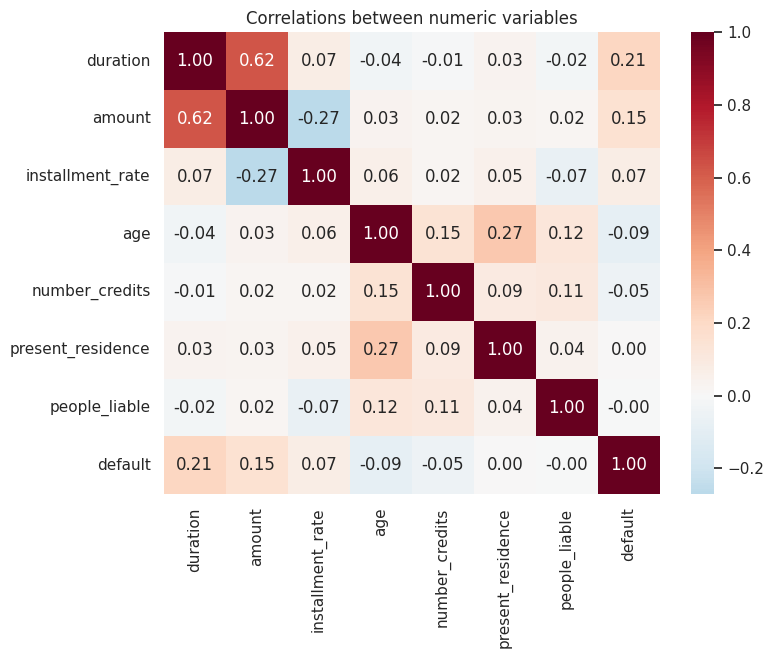

                    default_rate  loans
savings                                
Very low (< 100)            36.0    603
Low (100–500)               33.0    103
Medium (500–1,000)          17.5     63
None / unknown              17.5    183
High (1,000+)               12.5     48 

                            default_rate  loans
credit_history                                 
No loans / all repaid               62.5     40
All loans with us repaid            57.1     49
Current loans paid on time          31.9    530
Delays in the past                  31.8     88
Has loans at other lenders          17.1    293 

                     default_rate  loans
employment_duration                     
Less than 1 year             40.7    172
Unemployed                   37.1     62
1–4 years                    30.7    339
7+ years                     25.3    253
4–7 years                    22.4    174 

               default_rate  loans
other_debtors                     
Co-applicant         

In [5]:
num_cols = ["duration", "amount", "installment_rate", "age", "number_credits", "present_residence", "people_liable", "default"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlations between numeric variables"); plt.show()

for c in ["savings", "credit_history", "employment_duration", "other_debtors"]:
    print((df.groupby(c).default.agg(["mean", "size"]).rename(columns={"mean": "default_rate", "size": "loans"})
           .assign(default_rate=lambda d: (d.default_rate * 100).round(1)).sort_values("default_rate", ascending=False)), "\n")

**EDA takeaways**
- **Account balance matters most.** Applicants with a low or overdrawn balance default about half the time, versus about 12% for those with no current account at ABC Ltd.
- **Longer tenure means more risk.** Defaulted loans had noticeably longer tenures.
- **Low savings, short job tenure and no guarantor** all go with higher default rates.
- **Amount rises with tenure** (correlation of about 0.62), which makes a linear model of the loan amount sensible.
- **A counter-intuitive pattern:** applicants who *already have loans at other lenders* default *less*. This is a known quirk of this dataset. Such applicants were screened more strictly in the past, so only the safer ones got loans. We keep the variable but flag the issue for managers.

## 4. Model 1 — Linear regression: typical loan amount

**Purpose:** give credit officers a benchmark. *"Borrowers with this profile, purpose and tenure typically borrow X."* A request far above the benchmark deserves a closer look at need and repayment capacity.

In [6]:
AMT_NUM = ["duration", "installment_rate", "age", "number_credits"]
AMT_CAT = ["purpose", "job", "property", "housing", "savings", "telephone"]
Xa, ya = df[AMT_NUM + AMT_CAT], df["amount"]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.25, random_state=RANDOM_STATE)

Xd = pd.get_dummies(Xa_tr, columns=AMT_CAT, drop_first=True).astype(float)
ols = sm.OLS(ya_tr, sm.add_constant(Xd)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 amount   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.579
Method:                 Least Squares   F-statistic:                     40.57
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          1.37e-122
Time:                        06:13:48   Log-Likelihood:                -6717.1
No. Observations:                 750   AIC:                         1.349e+04
Df Residuals:                     723   BIC:                         1.361e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [7]:
vif = pd.DataFrame({"feature": Xd.columns,
                    "VIF": [variance_inflation_factor(Xd.values, i) for i in range(Xd.shape[1])]})
vif.sort_values("VIF", ascending=False).head(8).round(1)

,feature,VIF
7,purpose_Home appliances,23.2
8,purpose_New vehicle,20.5
5,purpose_Electronics,16.5
12,purpose_Used vehicle,11.6
9,purpose_Other,10.7
19,housing_Own,5.8
11,purpose_Skill training,5.5
24,savings_Very low (< 100),5.3


**Reading the OLS output.**
- Every extra month of tenure adds a roughly constant amount to the loan.
- The **installment rate has a negative coefficient**: borrowers whose EMI is a large share of income tend to take *smaller* loans.
- **Managers and self-employed applicants, and used-vehicle and business loans,** are larger than average.
- **VIF check.** Most VIFs are low. The high VIFs sit on the `purpose` dummies, because the reference category (Business) has only 9 loans. This inflates their standard errors but does not affect the predictions, which are all the app uses.

In [8]:
def preprocessor(num, cat):
    return ColumnTransformer([("num", StandardScaler(), num),
                              ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat)])

linreg = Pipeline([("prep", preprocessor(AMT_NUM, AMT_CAT)), ("model", LinearRegression())]).fit(Xa_tr, ya_tr)
pa = linreg.predict(Xa_te)
lin_metrics = {"r2": r2_score(ya_te, pa), "mae": mean_absolute_error(ya_te, pa),
               "rmse": np.sqrt(mean_squared_error(ya_te, pa))}
cv_r2 = cross_val_score(linreg, Xa, ya, cv=5, scoring="r2")
print(f"Test R²: {lin_metrics['r2']:.3f} | MAE: {lin_metrics['mae']:,.0f} | RMSE: {lin_metrics['rmse']:,.0f}")
print(f"5-fold CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# Robustness check: log(amount) handles the right-skew
log_r2 = cross_val_score(linreg, Xa, np.log(ya), cv=5, scoring="r2").mean()
print(f"5-fold CV R² with log(amount): {log_r2:.3f}")

Test R²: 0.535 | MAE: 1,115 | RMSE: 1,627
5-fold CV R²: 0.553 ± 0.021
5-fold CV R² with log(amount): 0.608


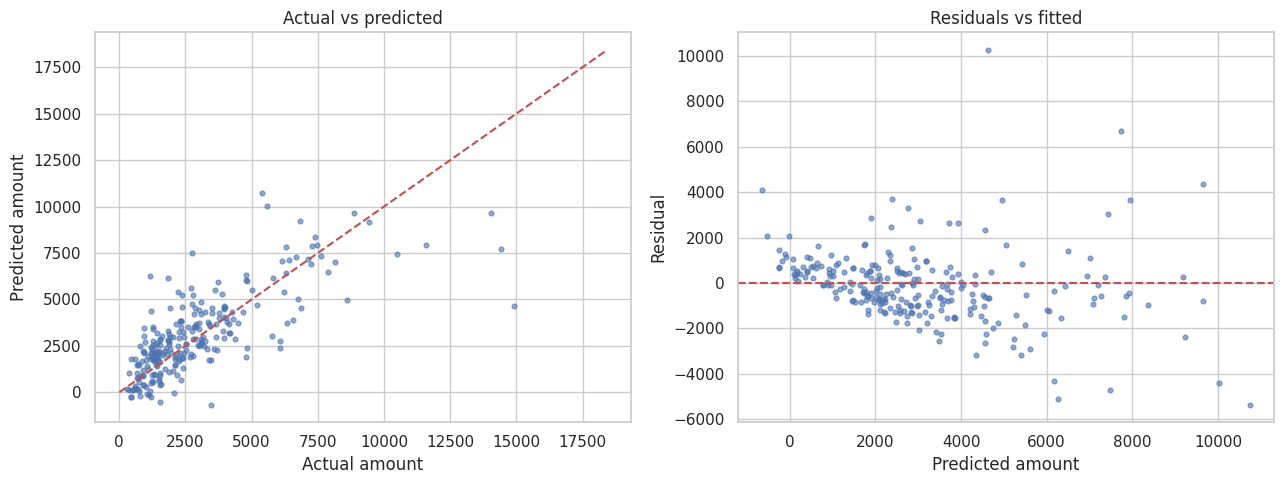

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(ya_te, pa, s=12, alpha=.6); lims = [0, ya.max()]; ax[0].plot(lims, lims, "r--")
ax[0].set(xlabel="Actual amount", ylabel="Predicted amount", title="Actual vs predicted")
ax[1].scatter(pa, ya_te - pa, s=12, alpha=.6); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="Predicted amount", ylabel="Residual", title="Residuals vs fitted")
plt.tight_layout(); plt.show()

**Interpretation.** The model explains a little over half of the variation in loan size (R² ≈ 0.53). That is reasonable for individual borrowing decisions, which depend on things the data can't see, such as the price of the specific car. Residuals fan out for large loans. A log model fits slightly better (R² ≈ 0.61), but it is harder for managers to read. We keep the simple linear model in the app and use it only to flag *unusually large* requests, not to set loan limits.

## 5. Model 2 — Logistic regression: probability of default

**Choices**
- 18 predictors covering the loan, the applicant, their money and their credit record. Sex/marital status and nationality are excluded.
- `class_weight="balanced"`, so the model pays proper attention to the 30% who defaulted.
- Mild regularisation (`C = 0.3`) to keep coefficients stable with only 1,000 loans. Cross-validation below shows that values from 0.03 to 0.3 perform almost identically (AUC ≈ 0.77), so the exact choice matters little.

In [10]:
DEF_NUM = ["duration", "amount", "installment_rate", "age", "number_credits", "present_residence", "people_liable"]
DEF_CAT = ["status", "credit_history", "purpose", "savings", "employment_duration", "other_debtors",
           "property", "other_installment_plans", "housing", "job", "telephone"]
X, y = df[DEF_NUM + DEF_CAT], df["default"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
for C_ in [0.03, 0.1, 0.3, 1, 3]:
    m = Pipeline([("prep", preprocessor(DEF_NUM, DEF_CAT)),
                  ("model", LogisticRegression(max_iter=3000, class_weight="balanced", C=C_))])
    print(f"C = {C_:<5} CV AUC = {cross_val_score(m, X_tr, y_tr, cv=cv, scoring='roc_auc').mean():.3f}")

C = 0.03  CV AUC = 0.772
C = 0.1   CV AUC = 0.773
C = 0.3   CV AUC = 0.770
C = 1     CV AUC = 0.763
C = 3     CV AUC = 0.758


### 5a. Statsmodels Logit — odds ratios and significance

In [11]:
Xl = pd.get_dummies(X_tr, columns=DEF_CAT, drop_first=True).astype(float)
logit_sm = sm.Logit(y_tr, sm.add_constant(Xl)).fit(disp=0)
print(f"Pseudo R² = {logit_sm.prsquared:.3f} | LLR p-value = {logit_sm.llr_pvalue:.2e}")
or_table = pd.DataFrame({"coef": logit_sm.params, "odds_ratio": np.exp(logit_sm.params),
                         "p_value": logit_sm.pvalues}).drop("const").sort_values("odds_ratio", ascending=False)
or_table["significant (p<0.05)"] = or_table.p_value < 0.05
or_table.round(3)

Pseudo R² = 0.255 | LLR p-value = 1.27e-27


,coef,odds_ratio,p_value,significant (p<0.05)
purpose_Skill training,2.008,7.452,0.139,False
savings_Very low (< 100),1.452,4.272,0.013,True
housing_Rent,1.382,3.981,0.016,True
purpose_Education,1.251,3.495,0.382,False
purpose_New vehicle,1.162,3.196,0.369,False
savings_Low (100–500),1.035,2.816,0.100,False
housing_Own,0.806,2.239,0.137,False
other_installment_plans_With another bank,0.793,2.211,0.003,True
"savings_Medium (500–1,000)",0.791,2.205,0.283,False
status_Low / overdrawn balance,0.764,2.147,0.064,False


**How to read the odds ratios** (per one-unit change, with other factors held constant):
- An odds ratio of about **1.03 for `duration`** means each extra month of tenure raises the odds of default by about 3%. A 12-month longer loan therefore has about 40% higher odds.
- An odds ratio of about **0.3 for `property_Real estate`** means real-estate collateral cuts the odds of default by about two-thirds, compared with having no property.
- **Statistically significant (p < 0.05):** tenure, EMI burden, very low savings, renting, EMIs with another bank, collateral, current-account status and loans at other lenders.
- A **guarantor** points the right way (odds ratio ≈ 0.47), but only 52 loans had one, so the estimate is not significant.

### 5b. Scikit-learn pipeline — the version used in the app

In [12]:
logit = Pipeline([("prep", preprocessor(DEF_NUM, DEF_CAT)),
                  ("model", LogisticRegression(max_iter=3000, class_weight="balanced", C=0.3))]).fit(X_tr, y_tr)
p_te = logit.predict_proba(X_te)[:, 1]
pred = (p_te >= 0.5).astype(int)
logit_metrics = {"accuracy": accuracy_score(y_te, pred), "precision": precision_score(y_te, pred),
                 "recall": recall_score(y_te, pred), "f1": f1_score(y_te, pred), "roc_auc": roc_auc_score(y_te, p_te)}
for k, v in logit_metrics.items():
    print(f"{k:10s}: {v:.3f}")
print(); print(classification_report(y_te, pred, target_names=["Repaid", "Defaulted"]))

accuracy  : 0.736
precision : 0.542
recall    : 0.773
f1        : 0.637
roc_auc   : 0.807

              precision    recall  f1-score   support

      Repaid       0.88      0.72      0.79       175
   Defaulted       0.54      0.77      0.64        75

    accuracy                           0.74       250
   macro avg       0.71      0.75      0.71       250
weighted avg       0.78      0.74      0.75       250



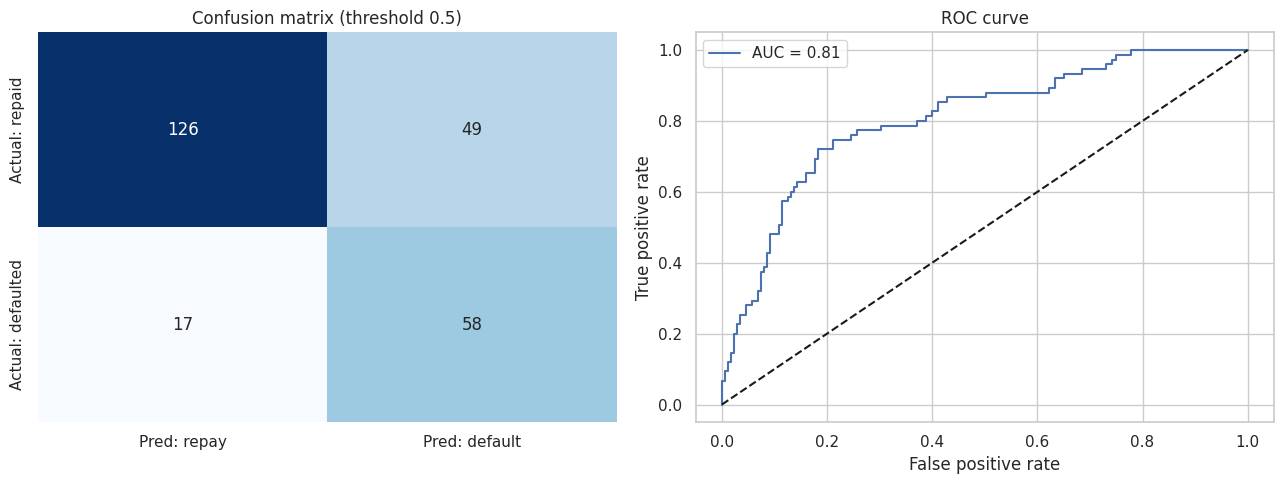

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(y_te, pred), annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["Pred: repay", "Pred: default"], yticklabels=["Actual: repaid", "Actual: defaulted"])
ax[0].set_title("Confusion matrix (threshold 0.5)")
fpr, tpr, _ = roc_curve(y_te, p_te)
ax[1].plot(fpr, tpr, label=f"AUC = {logit_metrics['roc_auc']:.2f}"); ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve"); ax[1].legend()
plt.tight_layout(); plt.show()

### 5c. Choosing the cut-off — a business decision, not a statistical one

In [14]:
# Illustrative cost: a missed defaulter loses ~5x what a wrongly-declined good borrower costs (lost margin)
COST_FN, COST_FP = 5, 1
rows = []
for t in np.arange(0.2, 0.81, 0.05):
    pr = (p_te >= t).astype(int)
    fn = ((pr == 0) & (y_te == 1)).sum(); fp = ((pr == 1) & (y_te == 0)).sum()
    rows.append({"cut-off": round(t, 2), "flagged": pr.sum(), "defaulters caught": ((pr == 1) & (y_te == 1)).sum(),
                 "missed defaulters": fn, "good borrowers flagged": fp,
                 "recall": round(recall_score(y_te, pr), 2), "precision": round(precision_score(y_te, pr), 2),
                 "relative cost": COST_FN * fn + COST_FP * fp})
thr = pd.DataFrame(rows)
best = thr.loc[thr["relative cost"].idxmin(), "cut-off"]
print(f"Lowest-cost cut-off under a 5:1 cost ratio: {best}")
thr

Lowest-cost cut-off under a 5:1 cost ratio: 0.35


,cut-off,flagged,defaulters caught,missed defaulters,good borrowers flagged,recall,precision,relative cost
0,0.20,191,71,4,120,0.95,0.37,140
1,0.25,180,69,6,111,0.92,0.38,141
2,0.30,164,66,9,98,0.88,0.40,143
3,0.35,146,65,10,81,0.87,0.45,131
4,0.40,134,62,13,72,0.83,0.46,137
5,0.45,119,59,16,60,0.79,0.50,140
6,0.50,107,58,17,49,0.77,0.54,134
7,0.55,95,56,19,39,0.75,0.59,134
8,0.60,82,51,24,31,0.68,0.62,151
9,0.65,69,45,30,24,0.60,0.65,174


Missing a defaulter usually costs a lender far more than wrongly flagging a good borrower. Under an illustrative 5:1 cost ratio, the **lowest-cost cut-off is 0.35**, and costs stay fairly flat up to about 0.55. Above 0.6, costs rise fast, because too many defaulters slip through. In the app we therefore use three bands rather than a single yes/no:
- **Low (< 35%)**: approve on standard terms.
- **Medium (35–60%)**: approve with conditions.
- **High (> 60%)**: refer to the credit committee or ask for mitigation.

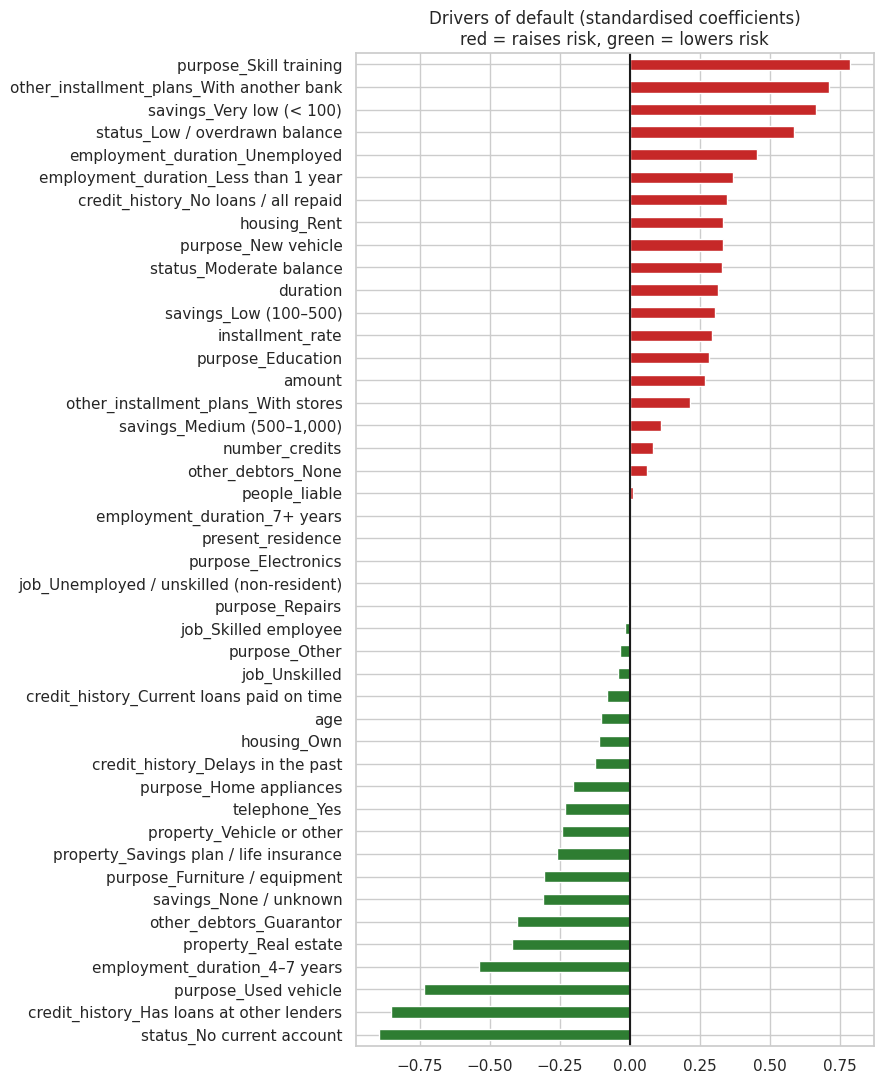

In [15]:
names = [n.split("__", 1)[1] for n in logit.named_steps["prep"].get_feature_names_out()]
imp = pd.Series(logit.named_steps["model"].coef_.ravel(), index=names).sort_values()
plt.figure(figsize=(9, 11))
imp.plot.barh(color=np.where(imp > 0, "#c62828", "#2e7d32")); plt.axvline(0, color="k")
plt.title("Drivers of default (standardised coefficients)\nred = raises risk, green = lowers risk")
plt.tight_layout(); plt.show()

## 6. Linking the two models: are unusually large requests riskier?

In [16]:
df["TypicalAmount"] = linreg.predict(df[AMT_NUM + AMT_CAT]).clip(250)
df["AmountGapPct"] = (df.amount - df.TypicalAmount) / df.TypicalAmount * 100
df["AmountBand"] = pd.cut(df.AmountGapPct, [-np.inf, -30, 50, np.inf],
                          labels=["Well below typical", "In usual range", "50%+ above typical"])
gap = df.groupby("AmountBand", observed=True).agg(loans=("default", "size"), default_rate=("default", "mean"))
gap["default_rate"] = (gap.default_rate * 100).round(1)
gap

,loans,default_rate
AmountBand,,
Well below typical,298,32.9
In usual range,505,28.9
50%+ above typical,197,28.4


**An honest negative finding.** Requests far above the typical amount do *not* default more often: the rates are about 28–33% in every band. The amount itself is already inside the logistic model, and once tenure and the borrower profile are known, "asking for more than peers" adds no extra warning.

So the linear model is best used as a **due-diligence prompt** (verify need, quotations and repayment capacity) rather than as a risk signal. The logistic model does the risk prediction. This is also a useful discussion point for the user study: a tool can be statistically sound and still offer managers less than they expect.

In [17]:
scored = X_te.copy()
scored["risk_%"] = (p_te * 100).round(1)
scored["actual"] = y_te.map({0: "Repaid", 1: "Defaulted"})
scored.sort_values("risk_%", ascending=False)[["purpose", "amount", "duration", "status", "savings",
                                               "credit_history", "risk_%", "actual"]].head(10)

,purpose,amount,duration,status,savings,credit_history,risk_%,actual
938,Skill training,6288,60,Moderate balance,Very low (< 100),Current loans paid on time,96.1,Defaulted
832,Other,11816,45,Low / overdrawn balance,Very low (< 100),No loans / all repaid,95.5,Defaulted
915,Furniture / equipment,18424,48,Moderate balance,Very low (< 100),No loans / all repaid,94.5,Defaulted
788,Skill training,6224,48,Moderate balance,Very low (< 100),Delays in the past,94.0,Defaulted
332,New vehicle,7408,60,Moderate balance,Low (100–500),Current loans paid on time,93.6,Defaulted
229,Electronics,3149,24,Low / overdrawn balance,Very low (< 100),Current loans paid on time,93.5,Repaid
522,Electronics,7119,48,Low / overdrawn balance,Very low (< 100),No loans / all repaid,93.5,Defaulted
11,Other,4308,48,Low / overdrawn balance,Very low (< 100),Current loans paid on time,92.2,Defaulted
818,Furniture / equipment,15857,36,Low / overdrawn balance,Very low (< 100),Current loans paid on time,89.9,Repaid
602,Skill training,1837,24,Moderate balance,Very low (< 100),All loans with us repaid,89.1,Defaulted


## 7. Managerial insights

1. **Savings and account behaviour are the clearest early-warning signals.** Very low savings is significantly linked to default, and a low or overdrawn balance points the same way (default rate about 49% versus 30% overall). Asking for bank statements and a margin deposit are cheap mitigations.
2. **Tenure is a lever the lender controls.** Every extra month raises risk, so offering a shorter tenure (with a smaller amount if needed) is the easiest way to move an applicant from High to Medium. The app's what-if panel shows this.
3. **Collateral significantly reduces risk, and a guarantor helps too.** Real-estate collateral cuts the odds of default by about two-thirds. Guarantors show lower default (19% vs 30%), although the sample is small. These are the natural conditions for "approve with conditions".
4. **Rented housing, a heavy EMI burden and EMIs with other banks** are significant risk factors. Skill-training and education loans and short job tenure point the same way, but the samples are small.
5. **Historical quirks:** patterns such as "loans at other lenders = safer" come from how the bank screened applicants in the past. Managers should treat them with caution. This is a key reason explainability matters.
6. **The amount benchmark is not a risk signal.** Large-for-profile requests default at the same rate as others, so use it for due diligence only.
7. **Limits:** the model ranks risk well (AUC ≈ 0.8) but flags many good borrowers, and it has only seen *approved* loans. It should trigger closer checks, not automatic rejection.

## 8. Save models and metrics

In [18]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(logit, "models/default_logit.pkl")
joblib.dump(linreg, "models/amount_linreg.pkl")
with open("models/metrics.json", "w") as f:
    json.dump({"logistic": {k: float(v) for k, v in logit_metrics.items()},
               "linear": {k: float(v) for k, v in lin_metrics.items()},
               "base_default_rate": float(y.mean())}, f, indent=2)
print(os.listdir("models"))

['default_logit.pkl', 'amount_linreg.pkl', 'metrics.json']


> The Streamlit app retrains these same two pipelines from the CSV at start-up (`model_utils.py`). This avoids scikit-learn version clashes between Colab and Streamlit Cloud. The saved `.pkl` files are kept as evidence of the trained models.

## 9. Deployment
1. Upload the project to a public GitHub repository. The steps are in `README.md`.
2. On **share.streamlit.io**, go to **Create app**, choose the repository and branch `main`, set the main file to `app.py`, and click **Deploy**.
3. The resulting URL is the app link for submission.